# 03 - Logistic Regression

Train and evaluate `LogisticRegression` on the lung cancer dataset.
- Hyperparameter tuning with GridSearchCV
- Confusion matrix, classification report
- Save trained model to `models/`

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, matthews_corrcoef,
                             confusion_matrix, classification_report, roc_curve)
import joblib
import warnings
warnings.filterwarnings('ignore')

In [2]:
# Load processed data
PROCESSED = Path('..') / 'data' / 'processed'
X_train = pd.read_csv(PROCESSED / 'X_train.csv').astype(float)
X_test = pd.read_csv(PROCESSED / 'X_test.csv').astype(float)
y_train = pd.read_csv(PROCESSED / 'y_train.csv').values.ravel().astype(int)
y_test = pd.read_csv(PROCESSED / 'y_test.csv').values.ravel().astype(int)
print(f"Train: {X_train.shape}, Test: {X_test.shape}")

Train: (447, 15), Test: (112, 15)


In [3]:
# Hyperparameter tuning with GridSearchCV
param_grid = {
    'C': [0.01, 0.1, 1, 10, 100],
    'penalty': ['l1', 'l2'],
    'solver': ['liblinear'],
    'class_weight': [None, 'balanced']
}

lr = LogisticRegression(max_iter=1000, random_state=42)
grid = GridSearchCV(lr, param_grid, cv=5, scoring='f1', n_jobs=-1)
grid.fit(X_train, y_train)

print(f"Best params: {grid.best_params_}")
print(f"Best CV F1: {grid.best_score_:.4f}")

Best params: {'C': 0.01, 'class_weight': 'balanced', 'penalty': 'l2', 'solver': 'liblinear'}
Best CV F1: 0.9504


In [4]:
# Evaluate best model on test set
best_lr = grid.best_estimator_
y_pred = best_lr.predict(X_test)
y_prob = best_lr.predict_proba(X_test)[:, 1]

acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_prob)
mcc = matthews_corrcoef(y_test, y_pred)

print("=== Logistic Regression - Test Results ===")
print(f"Accuracy:  {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall:    {rec:.4f}")
print(f"F1-Score:  {f1:.4f}")
print(f"AUC-ROC:   {auc:.4f}")
print(f"MCC:       {mcc:.4f}")
print(f"\nClassification Report:\n{classification_report(y_test, y_pred)}")

=== Logistic Regression - Test Results ===
Accuracy:  0.8839
Precision: 0.9126
Recall:    0.9592
F1-Score:  0.9353
AUC-ROC:   0.8929
MCC:       0.3848

Classification Report:
              precision    recall  f1-score   support

           0       0.56      0.36      0.43        14
           1       0.91      0.96      0.94        98

    accuracy                           0.88       112
   macro avg       0.73      0.66      0.69       112
weighted avg       0.87      0.88      0.87       112



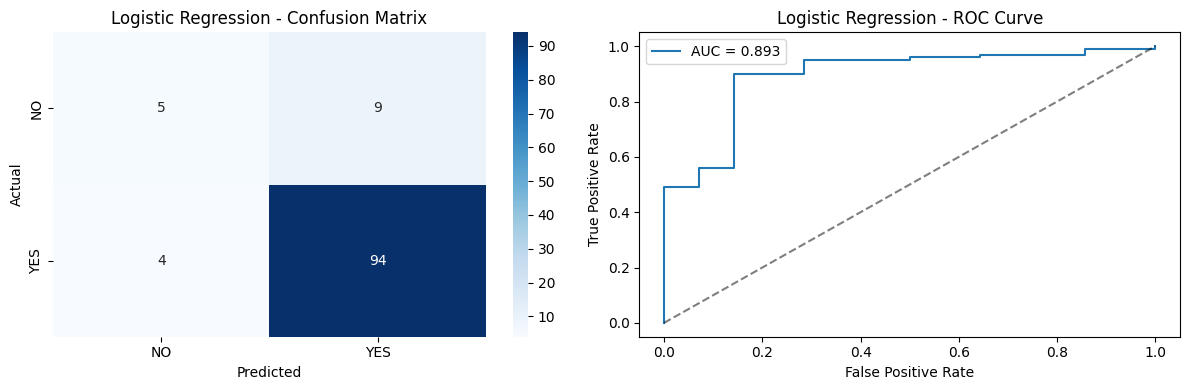

In [5]:
# Confusion Matrix & ROC Curve
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['NO', 'YES'], yticklabels=['NO', 'YES'])
axes[0].set_title('Logistic Regression - Confusion Matrix')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

# ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_prob)
axes[1].plot(fpr, tpr, label=f'AUC = {auc:.3f}')
axes[1].plot([0,1], [0,1], 'k--', alpha=0.5)
axes[1].set_title('Logistic Regression - ROC Curve')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].legend()

plt.tight_layout()
plt.savefig('../results/logistic_regression_results.png', dpi=150)
plt.show()

In [7]:
# Save model and results
MODELS_DIR = Path('..') / 'models'
joblib.dump(best_lr, MODELS_DIR / 'logistic_regression.pkl')

results = pd.DataFrame([{
    'Model': 'Logistic Regression',
    'Accuracy': acc, 'Precision': prec, 'Recall': rec,
    'F1': f1, 'AUC': auc, 'MCC': mcc
}])
results.to_csv(Path('..') / 'results' / 'logistic_regression_metrics.csv', index=False)
print("Model saved to models/logistic_regression.pkl")
print("Metrics saved to results/logistic_regression_metrics.csv")

Model saved to models/logistic_regression.pkl
Metrics saved to results/logistic_regression_metrics.csv
